In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib
font = {'family' : 'times',
        'weight' : 'bold',
        'size'   : 18}

matplotlib.rc('font', **font)

### CONSTANTS
YR = 3.1536E7             # converting a year to seconds
LN2 = np.log(2)
SSAGE=4.571*10**9*YR      # age of solar system


dH_ice=3.34e5             # latent heat of ice melting (J/kg)
dH_hyd_mol=69e3           # heat of hydration (J/mol)
dH_hyd=dH_hyd_mol/240*1e3 # Coverting to J/kg rock altered

Mf_react = 36/240              
melt_vs_react = dH_ice/dH_hyd 
WR = Mf_react*melt_vs_react   


# Radioactive isotopes:
# Heat Production (W/kg)
H0U238  = 94.65E-6
H0U235  = 568.7E-6
H0TH    = 26.38E-6
H0K     = 29.17E-6
H0FE    = 6.7E-2
H0AL    = 3.57E-1
H0MN    = 5.E-3
H0CA    = 1.53E-1

# Half-Lives
LAU238  = 4.47E9*YR
LAU235  = 7.0381E8*YR
LATH    = 14.01E9*YR
LAK     = 1.277E9*YR
LAFE    = 1.5E6*YR
LAAL    = 7.16E5*YR
LAMN    = 3.74E6*YR
LACA    = 0.103E5*YR

# Put in dictionary
LAs = dict({'U238': LAU238, 
              'U235':LAU235,
              'Th232':LATH,
              'K40':LAK,
              'Fe60':LAFE,
              'Al26':LAAL,
              'Mn53':LAMN,
              'Ca41':LACA})
H0s = dict({'U238': H0U238, 
              'U235':H0U235,
              'Th232':H0TH,
              'K40':H0K,
              'Fe60':H0FE,
              'Al26':H0AL,
              'Mn53':H0MN,
              'Ca41':H0CA})

def calcOriginAbund(abund,el):
    '''
    Given a present-day abundance of a radioisotope, calculates the abundance at the beginning of the solar system.
    '''
    if el not in LAs:
        print("Element "+el+" not in radiosotope list.")
    LAel=LAs[el]
    HLs=SSAGE/LAel
    return abund*(2**HLs)


def calcHeatProd(el,conc, cp, dt):
    '''
    Calculates the heat produced by the decay of a radioisotope
        el: radioisotope (string, one of the isotopes in the above dictionaries)
        conc: Current concentration of the isotope (fraction)
        cp: heat capacity (J/kg/K)
        dt: time step (seconds)
    '''
    return (H0s[el]*conc/cp*dt)

def calcDecayFrac(el,C0,time):
    '''
        el: radioisotope (string, one of the isotopes in the above dictionaries)
        C0: concentration (fraction)
        time: (seconds)
    '''
    return C0*np.exp(-LN2*time/LAs[el])


def cell_decay(dtime,sc):
    """
       Updates the abundances of Al26 after decaying for a set interval of time, dtime.
    """
    return calcDecayFrac('Al26',sc,dtime)


def cell_heat(sc,dtime,Cp):
    """
       Calculates the heat produced from decaying aluminium-26
    """
    DT = 0   # change in temperature
    i='Al26'
    DT = DT + calcHeatProd(i, sc, Cp, dtime)

    return DT

def cell_heat_K(sc,dtime,Cp):
    """
       Calculates the heat produced from decaying potassium-40.
    """
    DT = 0   # change in temperature
    i='K40'
    DT = DT + calcHeatProd(i, sc, Cp, dtime)

    return DT


def calcStep(Cp, K, rho, DR, timeC):
    """
       Calculates minimum time step.
    """
    alpha = K/(Cp*rho)
    DT = np.min(DR**2/alpha/3)
    return DT

def thermalCondStep(T,Cp,K,rho,Rads,dt):
    """
       Thermal coduction finite difference approximation.
    """
    nc = len(T)

    C = Rads
    DR = np.diff(C,append=0)
    DR[-1]=DR[-2]

    DT = dt

    D=np.zeros((nc,3))

    for i in range(0,nc):
        for j in range(0,3):
            if i==0:
                D[0,j]=K[0]/(rho[i]*Cp[0])
            elif i==nc-1:
                D[nc-1,j]=K[nc-1]/(rho[i]*Cp[nc-1])
            else:
                D[i,j]=(K[i]+K[i+(j-1)])/(rho[i]*Cp[i])/2.0

    dn = D[:,1]
    dp = D[:,2]
    dm = D[:,0]

    diagU = np.zeros(nc)
    diagC = np.zeros(nc)
    diagL = np.zeros(nc)

    for i in range(1,nc-1):
        diagL[i] = DT/(2.0*DR[i]*DR[i+1])*(dn[i]/(i)-dm[i])
        diagC[i] = 0.5+DT/(2.0*DR[i]*DR[i+1])*(dp[i]+dm[i])
        diagU[i] = -DT/(2.0*DR[i]*DR[i+1])*(dn[i]/(i)+dp[i])

    diagC[0] = 0.5 + DT/(DR[0]**2)*dn[0]
    diagU[0] = -DT/(DR[0]**2)*dn[0]

    # Calc source
    Hadd = np.zeros(nc)
    for i in range(0,nc-1):
        Hadd[i] = 0.5*T[i]
    Hadd[nc-2]=Hadd[nc-2]+DT/(2*DR[nc-2]**2)*(dn[nc-2]/(nc-2)+dp[nc-2])*T[nc-1]

    # Solve
    U = np.zeros(nc)
    GAM = np.zeros(nc)

    BET=diagC[0]
    U[0] = Hadd[0]/BET
    U[-1]=T[-1]

    for i in range(1,nc-1):
        GAM[i]=diagU[i-1]/BET
        BET=diagC[i]-diagL[i]*GAM[i]
        U[i] = (Hadd[i]-diagL[i]*U[i-1])/BET
    for i in range(nc-2,-1,-1):
        U[i]=U[i]-GAM[i+1]*U[i+1]

    return U


def calc_Cp(temp,WR):
    """
       Calculates Cp of rock and ice mix.
    """
    WR = WR*(temp<273)
    
    Cp_ice = 185+7.037*(temp)
    Cp_rock= 920
    
    Cp=Cp_ice*WR/(WR+1)+Cp_rock/(WR+1)
    
    return Cp
    
def calc_k(temp,WR):
    """
       Calculates thermal conductivity of rock and ice mix.
    """
    WR = WR*(temp<273)
    
    k_ice = 0.4685+488.12/(temp)
    k_rock= 4.2
    
    k=k_ice*WR/(WR+1)+k_rock/(WR+1)
    
    return k
    
def calc_rho(temp,WR):
    """
       Calculates density of rock and ice mix.
    """
    r_ice = 917
    r_rock= 3000
    
    r=r_ice*WR/(WR+1)+r_rock/(WR+1)
    
    return r+0*temp

def add_latent_heat(temp, new_temp, cps, WR):
    """
       adds latent heat.
    """
    ice_melt = 3.34e5  #J/kg
    rock_hyd = 2.875e5 #J/kg
    
    M_ice=WR/(WR+1)
    M_rock=1/(WR+1)
    
    Mf_react = 240/36
    M_rock_hyd_max=Mf_react*M_ice
    
    if M_rock_hyd_max<M_rock:
        M_rock=M_rock_hyd_max
        
    defecit=np.zeros(len(cps))
        
    for i in range(0,len(temp)):
        if temp[i]<273 and new_temp[i]>273:
            dT=(M_rock*rock_hyd/cps[i]-M_ice*ice_melt/cps[i])
            if dT<0:
                defecit[i]=dT
                dT=0
            new_temp[i]=new_temp[i]+dT
    
    return new_temp, defecit

def timeStep(temp, WR, nr, Rs, dt, Al26, defecit):
    """
       calculates thermal properties, adds decay heat, executes thermal conduction step, adds latent heat.
    """
    cps=calc_Cp(temp,WR)
    ks=calc_k(temp,WR)
    rhos=calc_rho(temp,WR)
    
    for i in range(0,nr):
        if cps[i]<500 or cps[i]>5000:
            print("Cp "+str(cps[i]))
        if ks[i]<0.5 or ks[i]>5:
            print("k "+str(ks[i]))
        if rhos[i]<500 or rhos[i]>5000:
            print("rho "+str(rhos[i]))
        
    for i in range(0,nr):
        # do not add heat to cell on surface
        if not i==nr-1:
            temp[i]+=cell_heat(Al26,dt,cps[i])
            temp[i]+=cell_heat_K(700e-9,dt,cps[i])
    
    new_temp=thermalCondStep(temp,cps,ks,rhos,Rs,dt)
    
    dt=new_temp-temp
    for i in range(0,nr):
        if defecit[i]>0 and dt[i]>0:
            if dt[i]>defecit[i]:
                new_temp[i]=new_temp[i]-defecit[i]
                defecit[i]=0
            else:
                new_temp[i]=temp[i]
                defecit[i]=defecit[i]-dt[i]
    
    new_temp, new_defecit=add_latent_heat(temp, new_temp, cps, WR)
    
    defecit=defecit+new_defecit
    
    return new_temp, defecit


def runModel(start, nt, dt, Rs, nr, rad, sT, Al26, WR):
    """
       Executes model
    """
    
    #cps = np.ones((nt,nr))*Cp
    #rhos = np.ones((nt,nr))*rho
    #ks = np.ones((nt,nr))*k
    
    Al26_arr = np.zeros(nt)
    
    dr = rad/nr
    
    temp = np.ones((nt,nr))*sT
    
    Al26=cell_decay(start,Al26)
    
    Al26_arr[0]=Al26
    
    defecit=np.zeros(nr)
    for i in range(0,nt-1):
        temp[i+1,:],deficit=timeStep(temp[i,:], WR, nr, Rs, dt, Al26, defecit)
        #temp[i+1,:]=timeStep(temp[i,:], ks[i,:], rhos[i,:], cps[i,:], nr, Rs, dt, Al26)
        Al26=cell_decay(dt,Al26)
        Al26_arr[i]=Al26
        
        #ks[i+1,:]=calc_k(temp[i+1,:])
        #rhos[i+1,:]=calc_Cp(temp[i+1,:])
        #cps[i+1,:]=calc_rho(temp[i+1,:])
        
    return temp, Al26_arr
        
def calc_shell_mass(r,dr,rho):
    """
       Calculates mass of spherical shell.
    """
    V= 4/3 * np.pi * (r**3 - (r-dr)**3) 
    M= V*rho
    return M

def mass_temp_hist(R,dr,nr,rho,T):
    """
       Generates a histogram of mass by temperature for thermal model.
    """
    M = np.zeros(nr)
    for i in range(0,nr):
        M[i] = calc_shell_mass(R[i],dr,rho)
    
    #fig, ax = plt.subplots()
    #ax.hist(T, nbins, weights=M)
    
    nbins=np.linspace(100,2000,30)
    return np.histogram(T, nbins, weights = M)

def choose_color(top_val):
    """
       temperature bounds for figures.
    """
    if top_val<SM_K:
        return colors[0]
    if top_val<S1_K:
        return colors[1]
    if top_val<S2_K:
        return colors[2]
    if top_val<S3_K:
        return colors[3]
    if top_val<S4_K:
        return colors[4]
    else:
        return colors[5]

In [2]:
# Figure colorbars

# Heating stage bounds (C)
SM=180-273-7
S1=0
S2=300
S3=500
S4=750

# Heating stage bounds (K)
SM_K=0
S1_K=273
S2_K=273+300
S3_K=273+500
S4_K=273+750

# Define value bounds
bounds = [SM, S1, S2, S3, S4]  # 5 breakpoints -> 6 bins
levels = [SM, S1, S2, S3, S4, 1000]
colors = ['#fde725','#A9A9A9', '#3b528b', '#5dc962', '#964B00','#E0115F']

# Create colormap
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries=[-np.inf, *bounds, np.inf], ncolors=len(colors))

# Figure 3a & 4a

In [88]:
WR=0.7
rho=calc_rho(0,WR);

nr=1000
rad=150000
nt=300
dt=4e4*YR
sT=180

Rs=np.linspace(0,rad,nr)
ts=np.arange(0,nt*dt,dt)

factor=1
Al_tot_abund=factor * 1.14/100
Al_26_27_start=5*10**-5   
Al26=Al_tot_abund*Al_26_27_start

start=2.0e6*YR

temp_map=np.zeros((nt,nr))
temp_map,Al26_arr=runModel(start, nt, dt, Rs, nr, rad, sT, Al26, WR)


5.699999999999999e-07


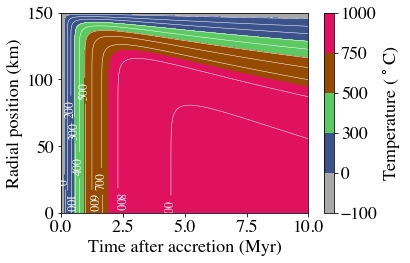

In [89]:
plt.figure(figsize=[6,4])
plt.contourf(ts/YR/1e6,Rs/1000,np.transpose(temp_map-273),cmap=cmap, norm=norm, levels=levels)
cb=plt.colorbar()
CS=plt.contour(ts/YR/1e6,Rs/1000,np.transpose(temp_map-273),np.linspace(0,1200,13),colors='w',linewidths=0.5)
plt.clabel(CS, inline=1, fontsize=12)
plt.xlim([0,10])
plt.xlabel("Time after accretion (Myr)")
plt.ylabel("Radial position (km)")
cb.ax.set_ylabel("Temperature ($^\circ$C)")
plt.tight_layout()
plt.savefig("fig3a.pdf")

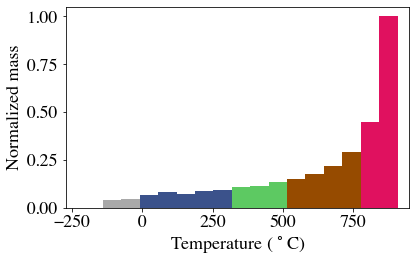

In [53]:
mTs=np.max(temp_map,axis=0)
dr=Rs[1]-Rs[0]

H, bins = mass_temp_hist(Rs+dr,dr,nr,rho,mTs)
    

col_list=np.array([])
for i in range(0,len(bins)-1):
    col_list=np.append(col_list, [choose_color(bins[i])]) 


plt.figure(figsize=(6,4))
plt.bar(bins[:-1]-273,H/np.max(H),width=(bins[1]-bins[0]),color=col_list)


plt.xlabel("Temperature ($^\circ$C)")
plt.ylabel("Normalized mass")
plt.xlim([0-273,S4_K+200-273])
#plt.title("Mass-temperature histogram for 1 body \n 2 Myr after CAI accretion, 500 km radius")
plt.tight_layout()

plt.savefig("fig4a.pdf")

# Figure 3b & 4b

5.699999999999999e-07


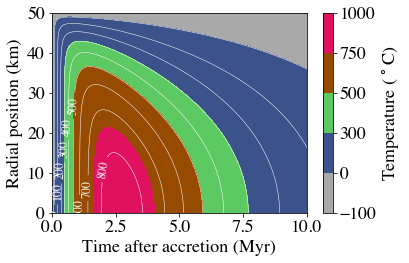

In [41]:
WR=0.7

nr=1000
rad=50000
nt=300
dt=4e4*YR
sT=180

Rs=np.linspace(0,rad,nr)
ts=np.arange(0,nt*dt,dt)

factor=1
Al_tot_abund=factor * 1.14/100
Al_26_27_start=5*10**-5   
Al26=Al_tot_abund*Al_26_27_start

start=1.95e6*YR

temp_map=np.zeros((nt,nr))
temp_map,Al26_arr=runModel(start, nt, dt, Rs, nr, rad, sT, Al26, WR)#Cp, rho, k)

plt.figure(figsize=[6,4])
plt.contourf(ts/YR/1e6,Rs/1000,np.transpose(temp_map-273),cmap=cmap, norm=norm, levels=levels)
cb=plt.colorbar()
CS=plt.contour(ts/YR/1e6,Rs/1000,np.transpose(temp_map-273),np.linspace(0,1200,13),colors='w',linewidths=0.5)
plt.clabel(CS, inline=1, fontsize=12)
plt.xlim([0,10])
plt.xlabel("Time after accretion (Myr)")
plt.ylabel("Radial position (km)")
cb.ax.set_ylabel("Temperature ($^\circ$C)")
plt.tight_layout()
plt.savefig("fig3b.pdf")

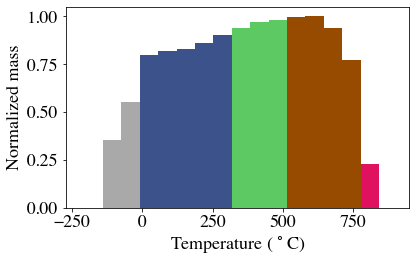

In [42]:
mTs=np.max(temp_map,axis=0)
dr=Rs[1]-Rs[0]

H, bins = mass_temp_hist(Rs+dr,dr,nr,rho,mTs)
    

col_list=np.array([])
for i in range(0,len(bins)-1):
    col_list=np.append(col_list, [choose_color(bins[i])]) 


plt.figure(figsize=(6,4))
plt.bar(bins[:-1]-273,H/np.max(H),width=(bins[1]-bins[0]),color=col_list)


plt.xlabel("Temperature ($^\circ$C)")
plt.ylabel("Normalized mass")

plt.xlim([0-273,S4_K+200-273])
plt.tight_layout()

plt.savefig("fig4b.pdf")


# Figure 3c & 4c

5.699999999999999e-07


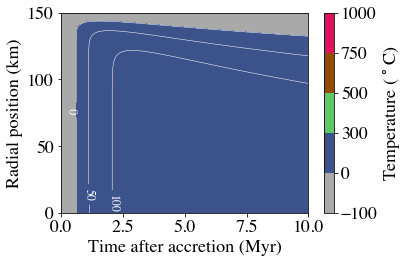

In [45]:
WR=0.7

nr=1000
rad=150000
nt=300
dt=4e4*YR
sT=190

Rs=np.linspace(0,rad,nr)
ts=np.arange(0,nt*dt,dt)

factor=1
Al_tot_abund=factor * 1.14/100
Al_26_27_start=5*10**-5   
Al26=Al_tot_abund*Al_26_27_start

start=3.5e6*YR

temp_map=np.zeros((nt,nr))
temp_map,Al26_arr=runModel(start, nt, dt, Rs, nr, rad, sT, Al26, WR) #Cp, rho, k)

plt.figure(figsize=[6,4])
plt.contourf(ts/YR/1e6,Rs/1000,np.transpose(temp_map-273),cmap=cmap, norm=norm, levels=levels)
cb=plt.colorbar()
CS=plt.contour(ts/YR/1e6,Rs/1000,np.transpose(temp_map-273),np.linspace(0,1200,25),colors='w',linewidths=0.5)
plt.clabel(CS, inline=1, fontsize=12)
plt.xlim([0,10])
plt.xlabel("Time after accretion (Myr)")
plt.ylabel("Radial position (km)")
cb.ax.set_ylabel("Temperature ($^\circ$C)")
plt.tight_layout()
plt.savefig("fig3c.pdf")

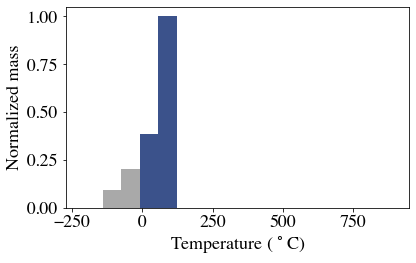

In [46]:
mTs=np.max(temp_map,axis=0)
dr=Rs[1]-Rs[0]

H, bins = mass_temp_hist(Rs+dr,dr,nr,rho,mTs)
    

col_list=np.array([])
for i in range(0,len(bins)-1):
    col_list=np.append(col_list, [choose_color(bins[i])]) 


plt.figure(figsize=(6,4))
plt.bar(bins[:-1]-273,H/np.max(H),width=(bins[1]-bins[0]),color=col_list)


plt.xlabel("Temperature ($^\circ$C)")
plt.ylabel("Normalized mass")

plt.xlim([0-273,S4_K+200-273])
plt.tight_layout()

plt.savefig("fig4c.pdf")

# Figure 3d & 4d

5.699999999999999e-07


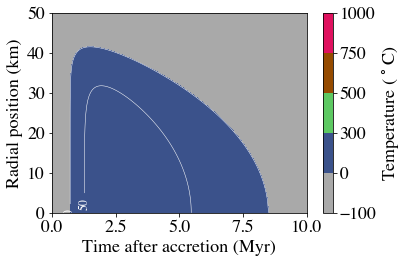

In [56]:
WR=0.7

nr=1000
rad=50000
nt=300
dt=4e4*YR
sT=180

Rs=np.linspace(0,rad,nr)
ts=np.arange(0,nt*dt,dt)

factor=1
Al_tot_abund=factor * 1.14/100
Al_26_27_start=5*10**-5   
Al26=Al_tot_abund*Al_26_27_start

start=3.5e6*YR

temp_map=np.zeros((nt,nr))
temp_map,Al26_arr=runModel(start, nt, dt, Rs, nr, rad, sT, Al26, WR)

plt.figure(figsize=[6,4])
plt.contourf(ts/YR/1e6,Rs/1000,np.transpose(temp_map-273),cmap=cmap, norm=norm, levels=levels)
cb=plt.colorbar()
CS=plt.contour(ts/YR/1e6,Rs/1000,np.transpose(temp_map-273),np.linspace(0,1200,25),colors='w',linewidths=0.5)
plt.clabel(CS, inline=1, fontsize=12)
plt.xlim([0,10])
plt.xlabel("Time after accretion (Myr)")
plt.ylabel("Radial position (km)")
cb.ax.set_ylabel("Temperature ($^\circ$C)")
plt.tight_layout()
plt.savefig("fig3d.pdf")

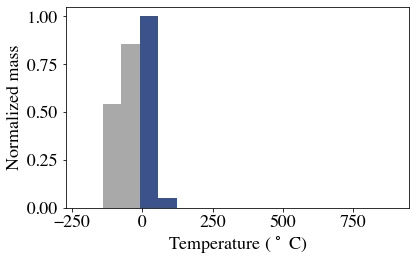

In [57]:
mTs=np.max(temp_map,axis=0)
dr=Rs[1]-Rs[0]

H, bins = mass_temp_hist(Rs+dr,dr,nr,rho,mTs)
    

col_list=np.array([])
for i in range(0,len(bins)-1):
    col_list=np.append(col_list, [choose_color(bins[i])]) 


plt.figure(figsize=(6,4))
plt.bar(bins[:-1]-273,H/np.max(H),width=(bins[1]-bins[0]),color=col_list)


plt.xlabel("Temperature ($^\circ$ C)")
plt.ylabel("Normalized mass")

plt.xlim([0-273,S4_K+200-273])
plt.tight_layout()

plt.savefig("fig4d.pdf")

# Figure 9

In [60]:
nB=10;

size_range=[5000,150000]
accretion_range=[2,4]

sizes=np.array([72.5756335,
26.4675359,
60.39077899,
10.7585,
43.25571087,
10.0645,
30.94617754,
68.80385414,
71.4380978,
150.6393088])*1000
#np.random.normal(50000, 50000, size=nB)
#sizes[sizes < 0] = 5000


acc_time=np.random.normal(3.5, 0.01, size=nB)
acc_time[acc_time < 0] = 1

H_all=np.zeros(29)
bins=np.linspace(100,2000,20)

maxT = np.zeros(nB)
Tmelt= np.zeros(nB)
TmaxCM=np.zeros(nB)
difft= np.zeros(nB)

ft=273.15
cmt=700

for i in range(0,nB):
    WR=0.7

    nr=100
    rad=sizes[i]
    nt=100
    dt=1e5*YR
    sT=180

    Rs=np.linspace(0,rad,nr)
    ts=np.arange(0,nt*dt,dt)

    factor=1
    Al_tot_abund=factor * 1.14/100  
    Al_26_27_start=5*10**-5   
    Al26=Al_tot_abund*Al_26_27_start

    start=acc_time[i]*YR*1e6

    temp_map=np.zeros((nt,nr))
    temp_map,Al26_arr=runModel(start, nt, dt, Rs, nr, rad, sT, Al26, WR) #Cp, rho, k)

    maxT[i] = np.max(temp_map)
    Tmelt[i]= ts[np.argmin(np.abs(ft-temp_map[:,0]))]
    TmaxCM[i]=ts[np.argmin(np.abs(cmt-temp_map[:,0]))]
    difft[i]=TmaxCM[i]-Tmelt[i]
    
    
    mTs=np.max(temp_map,axis=0)
    dr=Rs[1]-Rs[0]

    H, bins = mass_temp_hist(Rs+dr,dr,nr,rho,mTs)
    H_all=H_all+H

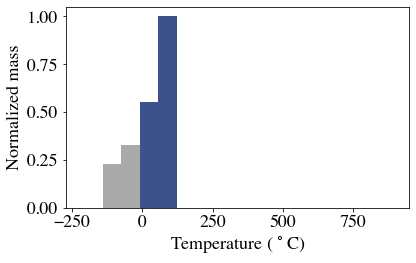

In [61]:
col_list=np.array([])
for i in range(0,len(bins)-1):
    col_list=np.append(col_list, [choose_color(bins[i])]) 

plt.figure(figsize=(6,4))
plt.bar(bins[:-1]-273,H_all/np.max(H_all),width=(bins[1]-bins[0]),color=col_list)
plt.xlabel("Temperature ($^\circ$C)")
plt.ylabel("Normalized mass")
plt.xlim([0-273,S4_K+200-273])
plt.tight_layout()
plt.savefig("fig9.pdf")

# Figure 2

In [63]:
nst=61
sts=np.linspace(2,5,nst)
print(sts)

OC_fact=1

nr=500
rad=25000
Rs=np.linspace(0,rad,nr)

maxT = np.zeros(nst)
Tmelt= np.zeros((nst,nr))
TmaxCM=np.zeros((nst,nr))
difft= np.zeros((nst,nr))

ft=273.15
cmt=S2_K

for i in range(0,nst):
    WR=0.7

    nt=100
    dt=1e5*YR
    sT=180

    ts=np.arange(0,nt*dt,dt)

    factor=1
    Al_tot_abund=1.14/100
    Al_26_27_start=5*10**-5   
    Al26=Al_tot_abund*Al_26_27_start

    start=sts[i]*YR*1e6

    temp_map=np.zeros((nt,nr))
    temp_map,Al26_arr=runModel(start, nt, dt, Rs, nr, rad, sT, Al26, WR)

    maxT[i] = np.max(temp_map)
    for j in range(0,nr):
        if np.max(temp_map[:,j])>ft:
            Tmelt[i,j]= ts[np.argmax(temp_map[:,j]>ft)]
        else:
            Tmelt[i,j]=np.nan
        if np.max(temp_map[:,j])>cmt:
            TmaxCM[i,j]=ts[np.argmax(temp_map[:,j]>cmt)]
        else:
            TmaxCM[i,j]=np.nan
        difft[i,j]=TmaxCM[i,j]-Tmelt[i,j]
        Tmelt[i,j]=Tmelt[i,j]+start
    
    mTs=np.max(temp_map,axis=0)
    dr=Rs[1]-Rs[0]

    H, bins = mass_temp_hist(Rs+dr,dr,nr,rho,mTs)

[2.   2.05 2.1  2.15 2.2  2.25 2.3  2.35 2.4  2.45 2.5  2.55 2.6  2.65
 2.7  2.75 2.8  2.85 2.9  2.95 3.   3.05 3.1  3.15 3.2  3.25 3.3  3.35
 3.4  3.45 3.5  3.55 3.6  3.65 3.7  3.75 3.8  3.85 3.9  3.95 4.   4.05
 4.1  4.15 4.2  4.25 4.3  4.35 4.4  4.45 4.5  4.55 4.6  4.65 4.7  4.75
 4.8  4.85 4.9  4.95 5.  ]


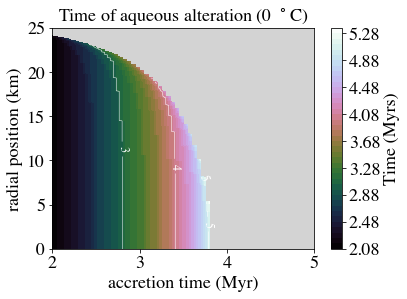

In [64]:
plt.figure(figsize=(6,4.5))
plt.contourf(sts,Rs/1000,np.transpose(Tmelt/YR/1e6),50,cmap='cubehelix')
cb=plt.colorbar()
CS=plt.contour(sts,Rs/1000,np.transpose(Tmelt/YR/1e6),np.linspace(2,9,8),colors='w',linewidths=0.5)
plt.clabel(CS, inline=1, fontsize=12)
plt.title('Time of aqueous alteration (0 $^\circ$C)',fontsize=18)
plt.xlabel('accretion time (Myr)')
plt.ylabel('radial position (km)')
cb.ax.set_ylabel("Time (Myrs)")
ax = plt.gca()
ax.set_facecolor("lightgray")
plt.tight_layout()
plt.savefig("fig2c.pdf")

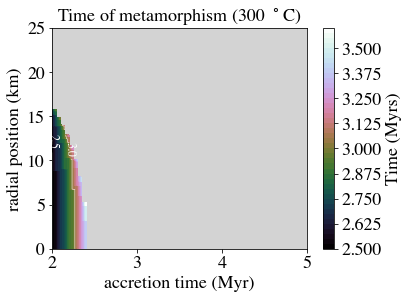

In [65]:
plt.figure(figsize=(6,4.5))
plt.contourf(sts,Rs/1000,np.transpose((Tmelt+difft)/YR/1e6),50,cmap='cubehelix')
cb=plt.colorbar()
CS=plt.contour(sts,Rs/1000,np.transpose((Tmelt+difft)/YR/1e6),np.linspace(0,5,11),colors='w',linewidths=0.5)
plt.clabel(CS, inline=1, fontsize=12)
plt.title('Time of metamorphism ('+str(S2_K-273)+' $^\circ$C)',fontsize=18)
plt.xlabel('accretion time (Myr)')
plt.ylabel('radial position (km)')
cb.ax.set_ylabel("Time (Myrs)")
ax = plt.gca()
ax.set_facecolor("lightgray")
plt.tight_layout()
plt.savefig("fig2d.pdf")

# Figure S1
## Accretion time vs Al26 content

In [99]:
nst=31
sts=np.linspace(2,4,nst)
print(sts)

nf=11
OC_fact=np.linspace(0.5,1.5,nf)
print(OC_fact)

maxT = np.zeros((nst,nf))
Tmelt= np.zeros((nst,nf))
TmaxCM=np.zeros((nst,nf))
difft= np.zeros((nst,nf))

ft=273.15
cmt=S2_K


for i in range(0,nst):
    for j in range(0,nf):
        WR=0.7

        nr=100
        rad=150000
        nt=300
        dt=1e4*YR
        sT=180

        Rs=np.linspace(0,rad,nr)
        ts=np.arange(0,nt*dt,dt)

        factor=OC_fact[j]
        Al_tot_abund=factor * 1.14/100
        Al_26_27_start=5*10**-5   
        Al26=Al_tot_abund*Al_26_27_start
        
        start=sts[i]*YR*1e6
        
        temp_map=np.zeros((nt,nr))
        temp_map,Al26_arr=runModel(start, nt, dt, Rs, nr, rad, sT, Al26, WR) #Cp, rho, k)
        
        maxT[i,j] = np.max(temp_map)
        if np.max(temp_map[:,0])>ft:
            Tmelt[i,j]= ts[np.argmax(temp_map[:,0]>ft)]
        else:
            Tmelt[i,j]=np.nan
        if np.max(temp_map[:,0])>cmt:
            TmaxCM[i,j]=ts[np.argmax(temp_map[:,0]>cmt)]
        else:
            TmaxCM[i,j]=np.nan
        difft[i,j]=TmaxCM[i,j]-Tmelt[i,j]
        

[2.         2.06666667 2.13333333 2.2        2.26666667 2.33333333
 2.4        2.46666667 2.53333333 2.6        2.66666667 2.73333333
 2.8        2.86666667 2.93333333 3.         3.06666667 3.13333333
 3.2        3.26666667 3.33333333 3.4        3.46666667 3.53333333
 3.6        3.66666667 3.73333333 3.8        3.86666667 3.93333333
 4.        ]
[0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5]


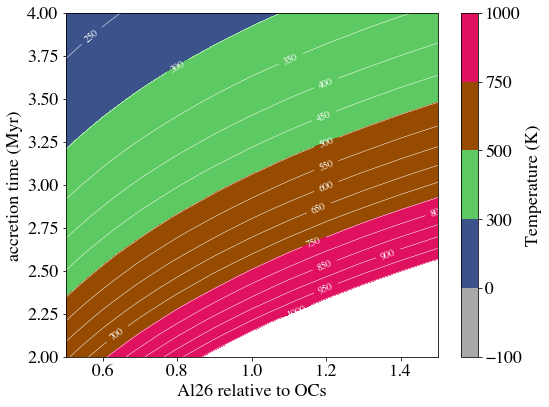

In [100]:
plt.figure(figsize=(8,6))
plt.contourf(OC_fact,sts,maxT,50,cmap=cmap, norm=norm, levels=levels)
cb=plt.colorbar()
CS=plt.contour(OC_fact,sts,maxT,np.linspace(0,1200,25),colors='w',linewidths=0.5)
plt.clabel(CS, inline=1, fontsize=10)
plt.xlabel('Al26 relative to OCs')
plt.ylabel('accretion time (Myr)')
cb.ax.set_ylabel("Temperature (K)")
plt.tight_layout()
plt.savefig("figS1.pdf")

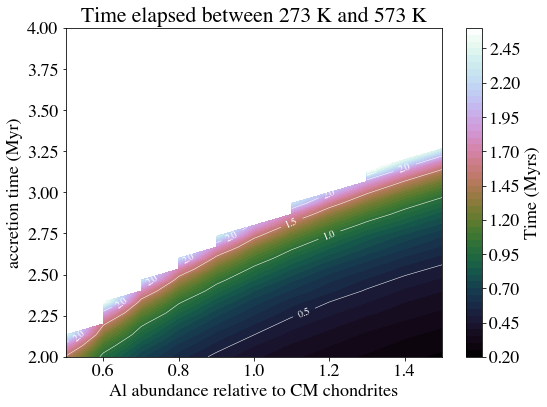

In [101]:
plt.figure(figsize=(8,6))
plt.contourf(OC_fact,sts,difft/YR/1e6,50,cmap='cubehelix')
cb=plt.colorbar()

CS=plt.contour(OC_fact,sts,difft/YR/1e6,np.linspace(0,5,11),colors='w',linewidths=0.5)
plt.clabel(CS, inline=1, fontsize=10)
plt.xlabel('Al abundance relative to CM chondrites')
plt.ylabel('accretion time (Myr)')
plt.title('Time elapsed between 273 K and '+str(S2_K)+' K')
cb.ax.set_ylabel("Time (Myrs)")
plt.tight_layout()
plt.savefig("figS1b.pdf")

# Figure S2
## Accretion time vs Heat capacity

In [93]:
nst=31
sts=np.linspace(2,5,nst)
print(sts)

nf=16
ks=np.linspace(0.5,4,nf)
Cps=np.linspace(1000,3000,nf)
WRs=np.linspace(0.2,1.5,nf)
print(WRs)

maxT = np.zeros((nst,nf))
Tmelt= np.zeros((nst,nf))
TmaxCM=np.zeros((nst,nf))

ft=273.15
cmt=700


for i in range(0,nst):
    for j in range(0,nf):
        WR=WRs[j]

        nr=100
        rad=500000
        nt=300
        dt=4e4*YR
        sT=180

        Rs=np.linspace(0,rad,nr)
        ts=np.arange(0,nt*dt,dt)

        factor=1
        Al_tot_abund=factor * 1.14/100
        Al_26_27_start=5*10**-5   
        Al26=Al_tot_abund*Al_26_27_start
        
        start=sts[i]*YR*1e6
        temp_map=np.zeros((nt,nr))
        temp_map,Al26_arr=runModel(start, nt, dt, Rs, nr, rad, sT, Al26, WR) #Cp, rho, k)
        
        maxT[i,j] = np.max(temp_map)
        Tmelt[i,j]= ts[np.argmin(np.abs(ft-temp_map[:,0]))]
        TmaxCM[i,j]=ts[np.argmin(np.abs(cmt-temp_map[:,0]))]
        
        

[2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5 3.6 3.7
 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9 5. ]
[0.2        0.28666667 0.37333333 0.46       0.54666667 0.63333333
 0.72       0.80666667 0.89333333 0.98       1.06666667 1.15333333
 1.24       1.32666667 1.41333333 1.5       ]


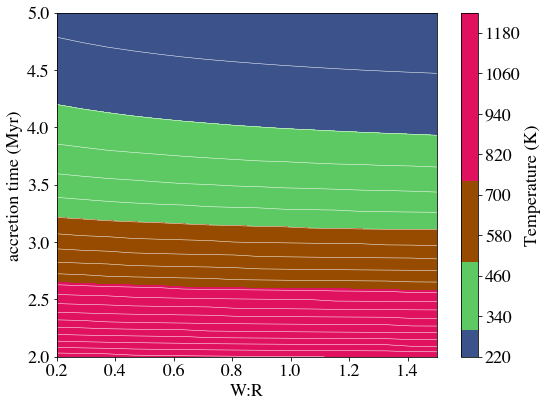

In [94]:
plt.figure(figsize=(8,6))
plt.contourf(WRs,sts,maxT,50,cmap=cmap, norm=norm)
cb=plt.colorbar()
plt.contour(WRs,sts,maxT,np.linspace(0,1200,25),colors='w',linewidths=0.5)
plt.clabel(CS, inline=1, fontsize=10)
plt.xlabel('W:R')
plt.ylabel('accretion time (Myr)')
cb.ax.set_ylabel("Temperature (K)")
plt.tight_layout()
plt.savefig("figS2.pdf")

# Figure 1
## Accretion time vs. Radius

In [95]:
nst=18
sts=np.linspace(1.6,5,nst)
print(sts)

ns=31
ss=np.linspace(5000,150000,ns)

maxT = np.zeros((nst,ns))
Tmelt= np.zeros((nst,ns))
TmaxCM=np.zeros((nst,ns))

ft=273.15
cmt=700


for i in range(0,nst):
    for j in range(0,ns):
        WR=0.7

        nr=100
        rad=ss[j]
        nt=300
        dt=4e4*YR
        sT=180

        Rs=np.linspace(0,rad,nr)
        ts=np.arange(0,nt*dt,dt)

        factor=1
        Al_tot_abund=factor * 1.14/100
        Al_26_27_start=5*10**-5   
        Al26=Al_tot_abund*Al_26_27_start
        
        start=sts[i]*YR*1e6
        temp_map=np.zeros((nt,nr))
        temp_map,Al26_arr=runModel(start, nt, dt, Rs, nr, rad, sT, Al26, WR)
        
        maxT[i,j] = np.max(temp_map)
        Tmelt[i,j]= ts[np.argmin(np.abs(ft-temp_map[:,0]))]
        TmaxCM[i,j]=ts[np.argmin(np.abs(cmt-temp_map[:,0]))]
        
        

[1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4 3.6 3.8 4.  4.2 4.4 4.6 4.8 5. ]


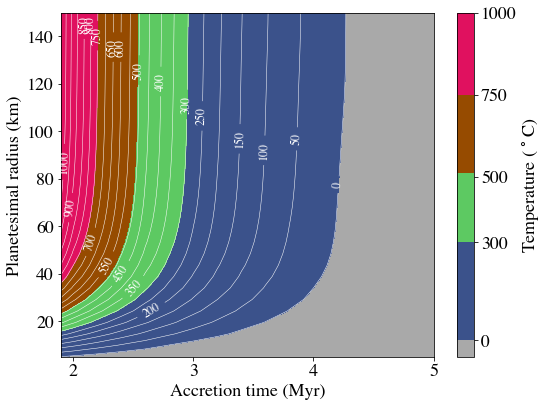

In [96]:
plt.figure(figsize=(8,6))
plt.contourf(sts,ss/1000,np.transpose(maxT-273),50,cmap=cmap, norm=norm)
cb=plt.colorbar()
cb.set_ticks([S1,S2,S3,S4,1000])

CS=plt.contour(sts,ss/1000,np.transpose(maxT-273),np.linspace(0,1000,21),colors='w',linewidths=0.5)
plt.clabel(CS, inline=1, fontsize=12)
plt.ylabel('Planetesimal radius (km)')
plt.xlabel('Accretion time (Myr)')
cb.ax.set_ylabel("Temperature ($^\circ$C)")
cb.ax.set_ylim(-50, 1000)
plt.xlim([1.9,5])
plt.tight_layout()
plt.savefig("figS3.pdf")

# Figure S3
## Accretion time vs thermal conductivity

In [97]:
nst=31
sts=np.linspace(2,5,nst)
print(sts)

nf=16
ks=np.linspace(0.5,4,nf)
print(ks)

maxT = np.zeros((nst,nf))
Tmelt= np.zeros((nst,nf))
TmaxCM=np.zeros((nst,nf))
vol_frac_alt=np.zeros((nst,nf))
vol_frac_melt=np.zeros((nst,nf))

ft=273.15
cmt=700


for i in range(0,nst):
    for j in range(0,nf):
        r_ind=0
        WR=0.7

        nr=100
        rad=50000
        nt=400
        dt=4e4*YR
        sT=180

        Rs=np.linspace(0,rad,nr)
        ts=np.arange(0,nt*dt,dt)

        factor=1
        Al_tot_abund=factor * 1.14/100
        Al_26_27_start=5*10**-5   
        Al26=Al_tot_abund*Al_26_27_start
        
        start=sts[i]*YR*1e6
        temp_map=np.zeros((nt,nr))
        temp_map,Al26_arr=runModel(start, nt, dt, Rs, nr, rad, sT, Al26, WR) #Cp, rho, k)
        
        not_done=1
        for m in range(nr-1,-1,-1):
            if np.max(temp_map[m,:])>cmt and not_done:
                r_ind=m
                not_done=0
        
        vol_frac_alt[i,j]=r_ind
        
        not_done=1
        for m in range(nr-1,-1,-1):
            if np.max(temp_map[m,:])>ft and not_done:
                r_ind=m
                not_done=0
        
        vol_frac_melt[i,j]=r_ind
        
        
        maxT[i,j] = np.max(temp_map)
        Tmelt[i,j]= ts[np.argmin(np.abs(ft-temp_map[:,0]))]
        TmaxCM[i,j]=ts[np.argmin(np. abs(cmt-temp_map[:,0]))]
        
        

[2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5 3.6 3.7
 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9 5. ]
[0.5        0.73333333 0.96666667 1.2        1.43333333 1.66666667
 1.9        2.13333333 2.36666667 2.6        2.83333333 3.06666667
 3.3        3.53333333 3.76666667 4.        ]


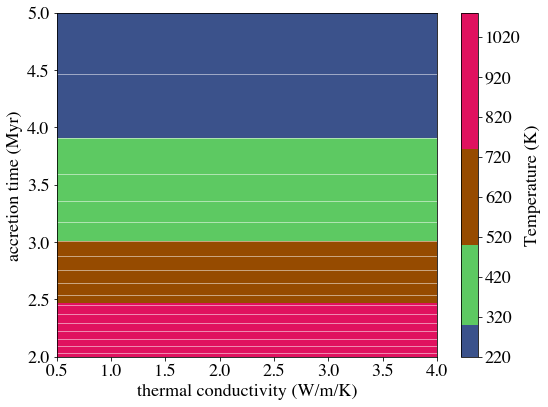

In [98]:
plt.figure(figsize=(8,6))
plt.contourf(ks,sts,maxT,50,cmap=cmap, norm=norm)
cb=plt.colorbar()
plt.contour(ks,sts,maxT,np.linspace(0,1200,25),colors='w',linewidths=0.5)
plt.clabel(CS, inline=1, fontsize=10)
plt.xlabel('thermal conductivity (W/m/K)')
plt.ylabel('accretion time (Myr)')
cb.ax.set_ylabel("Temperature (K)")
plt.tight_layout()
plt.savefig("figS4.pdf")

# Figure 8

In [3]:
# Read the CSV file into a DataFrame
df = pd.read_csv('heated_CM_chondrites.csv')
df2 = pd.read_csv('all_CMs.csv')

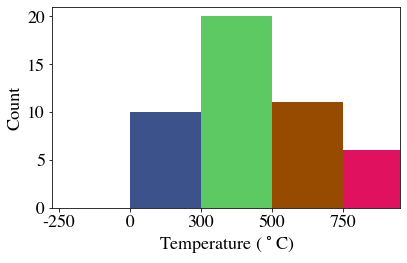

In [19]:
temp_dist=df['amt']
stage=df['Stage']
weights=df['Mass (g) ']

weights_all_CM=df2['Mass']


def extract_numbers(text):
    if isinstance(text, str):
        # Matches digits and optionally a single decimal point and more digits
        match = re.search(r'^-?\d+(\.\d+)?$', text)
        if match:
            return text
        else:
            return ''.join(filter(str.isdigit, text)) # Extract only digits
    return text

weights_all_CM = weights_all_CM.apply(extract_numbers)
weights_all_CM = pd.to_numeric(weights_all_CM, errors='coerce')

temp_all_CM=weights_all_CM*0

temp_dist_all=np.append(temp_all_CM,temp_dist.to_numpy(dtype=float))
weights_all=np.append(weights_all_CM,weights.to_numpy(dtype=float))

H, bins = np.histogram(temp_dist, bins=[0,250,500,750,1000])
    

col_list=np.array([])
for i in range(0,len(bins)-1):
    col_list=np.append(col_list, [choose_color(bins[i+1]+100)]) 


plt.figure(figsize=(6,4))
plt.bar(bins[:-1]+125,H,width=(bins[2]-bins[1]),color=col_list)
plt.xticks([-250,0,250,500,750,1000], ["-250","0","300","500","750","1000"])

plt.xlabel("Temperature ($^\circ$C)")
plt.ylabel("Count")

plt.xlim([0-273,S4_K+200-273])
plt.tight_layout()

plt.savefig("fig8a.pdf")

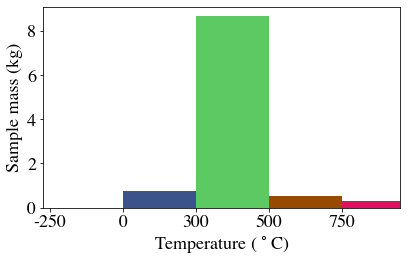

In [20]:
H, bins = np.histogram(temp_dist, bins=[0,250,500,750,1000],weights=weights)


col_list=np.array([])
for i in range(0,len(bins)-1):
    col_list=np.append(col_list, [choose_color(bins[i+1]+100)]) 


plt.figure(figsize=(6,4))
plt.bar(bins[:-1]+125,H/1000,width=(bins[2]-bins[1]),color=col_list)
plt.xticks([-250,0,250,500,750,1000], ["-250","0","300","500","750","1000"])


plt.xlabel("Temperature ($^\circ$C)")
plt.ylabel("Sample mass (kg)")

plt.xlim([0-273,S4_K+200-273])
plt.tight_layout()

plt.savefig("fig8b.pdf")

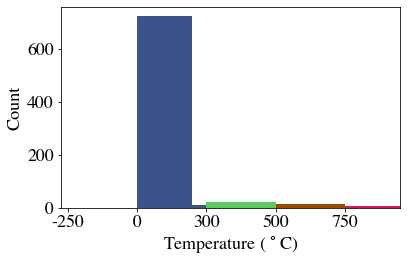

In [21]:
H_all, bins = np.histogram(temp_dist_all, bins=[-25,1,251,501,751,1001])
    

col_list=np.array([])
for i in range(0,len(bins)-1):
    if i==0:
        col_list=np.append(col_list, [choose_color(300)]) 
    else:
        col_list=np.append(col_list, [choose_color(bins[i+1]+100)]) 
    
H_all[0]=H_all[0]-H_all[1]-H_all[2]-H_all[3]-H_all[4]

widths=[200,bins[2]-bins[1],bins[2]-bins[1],bins[2]-bins[1],bins[2]-bins[1]]
plt.figure(figsize=(6,4))
plt.bar(bins[:-1]+125,H_all,width=widths,color=col_list)
plt.xticks([-250,0,250,500,750,1000], ["-250","0","300","500","750","1000"])


plt.xlabel("Temperature ($^\circ$C)")
plt.ylabel("Count")

plt.xlim([0-273,S4_K+200-273])
plt.tight_layout()

plt.savefig("fig8a.pdf")

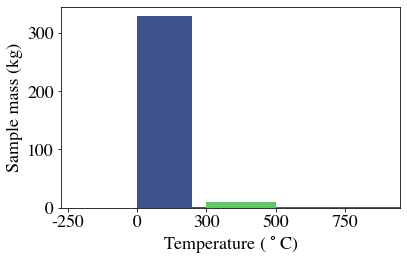

In [22]:
H_all, bins = np.histogram(temp_dist_all, bins=[-25,1,251,501,751,1001],weights=weights_all)

H_all[0]=H_all[0]-H_all[1]-H_all[2]-H_all[3]-H_all[4]

col_list=np.array([])
for i in range(0,len(bins)-1):
    if i==0:
        col_list=np.append(col_list, [choose_color(300)]) 
    else:
        col_list=np.append(col_list, [choose_color(bins[i+1]+100)]) 


widths=[200,bins[2]-bins[1],bins[2]-bins[1],bins[2]-bins[1],bins[2]-bins[1]]
plt.figure(figsize=(6,4))
plt.bar(bins[:-1]+125,H_all/1000,width=widths,color=col_list)
plt.xticks([-250,0,250,500,750,1000], ["-250","0","300","500","750","1000"])


plt.xlabel("Temperature ($^\circ$C)")
plt.ylabel("Sample mass (kg)")

plt.xlim([0-273,S4_K+200-273])
plt.tight_layout()

plt.savefig("fig8b.pdf")